# Actual Working with Arena Data

In [1]:
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")

In [2]:
ds_dict = dict(ds)['train']

In [3]:
ds_dict['category_tag'][0:5]

[{'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
  'criteria_v0.1': {'complexity': False,
   'creativity': False,
   'domain_knowledge': True,
   'problem_solving': True,
   'real_world': False,
   'specificity': False,
   'technical_accuracy': True},
  'if_v0.1': {'if': False, 'score': 1},
  'math_v0.1': {'math': False}},
 {'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
  'criteria_v0.1': {'complexity': True,
   'creativity': True,
   'domain_knowledge': True,
   'problem_solving': True,
   'real_world': True,
   'specificity': True,
   'technical_accuracy': True},
  'if_v0.1': {'if': True, 'score': 4},
  'math_v0.1': {'math': False}},
 {'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
  'criteria_v0.1': {'complexity': True,
   'creativity': False,
   'domain_knowledge': True,
   'problem_solving': True,
   'real_world': True,
   'specificity': True,
   'technical_accuracy': True},
  'if_v0.1': {'if': False, 'score': 3},


In [4]:
_ = [print(k) for k in ds_dict.features.keys()]

id
model_a
model_b
winner
evaluation_session_id
evaluation_order
conversation_a
conversation_b
full_conversation
conv_metadata
category_tag
language
is_code
timestamp


In [5]:
ds_dict['conv_metadata'][0]

{'sum_assistant_a_tokens': 1854,
 'header_count_a': {'h1': 0, 'h2': 0, 'h3': 8, 'h4': 0, 'h5': 0, 'h6': 0},
 'list_count_a': {'ordered': 0, 'unordered': 39},
 'bold_count_a': {'**': 65, '__': 0},
 'context_a_tokens': 11,
 'sum_assistant_b_tokens': 264,
 'header_count_b': {'h1': 1, 'h2': 0, 'h3': 0, 'h4': 0, 'h5': 0, 'h6': 0},
 'list_count_b': {'ordered': 0, 'unordered': 0},
 'bold_count_b': {'**': 5, '__': 0},
 'context_b_tokens': 11,
 'sum_user_tokens': 11,
 'turns': 1}

In [6]:
ds_dict[0]

{'id': 'c4b9710c-8d64-4bee-a0b0-94637ae4cc65',
 'model_a': 'gemini-2.5-pro',
 'model_b': 'claude-3-7-sonnet-20250219-thinking-32k',
 'winner': 'model_a',
 'evaluation_session_id': 'a333a685-37f9-474d-b703-f079d8329552',
 'evaluation_order': 1,
 'conversation_a': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Compare Tormenta20 with DnD5e',
     'image': None,
     'mimeType': None}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'Excellent question! Comparing **Tormenta20 (T20)** and **Dungeons & Dragons 5th Edition (D&D 5e)** is a fantastic way to understand different approaches to the d20 system. While they share a common ancestor (D&D 3rd Edition), they have evolved in vastly different directions.\n\nHere is a detailed comparison, broken down by key aspects of the games.\n\n---\n\n### **High-Level Philosophy**\n\n*   **D&D 5e:** Aims for **accessibility, streamlined play, and heroic fantasy**. It simplifies many of the complex rules of older 

In [7]:
k = set()
for i in range(5):
    k.update(ds_dict['category_tag'][i].keys())

In [8]:
k

{'creative_writing_v0.1', 'criteria_v0.1', 'if_v0.1', 'math_v0.1'}

## Examining Only Coding Problems

### Initial Filtering

In [9]:
idxs = ds_dict['is_code']

In [10]:
ds_dict[idxs[:50]]['conversation_a']

[[{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Compare Tormenta20 with DnD5e',
     'image': None,
     'mimeType': None}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'Excellent question! Comparing **Tormenta20 (T20)** and **Dungeons & Dragons 5th Edition (D&D 5e)** is a fantastic way to understand different approaches to the d20 system. While they share a common ancestor (D&D 3rd Edition), they have evolved in vastly different directions.\n\nHere is a detailed comparison, broken down by key aspects of the games.\n\n---\n\n### **High-Level Philosophy**\n\n*   **D&D 5e:** Aims for **accessibility, streamlined play, and heroic fantasy**. It simplifies many of the complex rules of older editions to be welcoming to new players. Its design philosophy is "rulings, not rules," encouraging Dungeon Masters to make calls on the fly. It is built to be setting-agnostic, though the Forgotten Realms is its default.\n*   **Tormenta20:** Aims for **deep cha

In [11]:
import numpy as np

In [12]:
en_idxs = (np.array(ds_dict['language']) == 'en')

In [13]:
en_idxs

array([ True, False,  True, ..., False,  True,  True])

In [14]:
code_idxs = ds_dict['is_code']

In [15]:
final_idxs = en_idxs & code_idxs

In [16]:
final_idxs

array([False, False,  True, ..., False,  True, False])

In [17]:
final_ds = ds_dict[final_idxs]

In [18]:
final_idxs.sum()

24366

In [19]:
en_idxs.sum()

71175

In [20]:
np.array(code_idxs).sum()

39363

In [21]:
model_as = set(final_ds['model_a'])
model_bs = set(final_ds['model_b'])
candidates = model_as.union(model_bs)

In [22]:
candidates_idxs = {candidates : i for i, candidates in enumerate(candidates)}

In [23]:
candidates_idxs

{'gemini-2.5-pro': 0,
 'claude-3-7-sonnet-20250219-thinking-32k': 1,
 'claude-3-5-sonnet-20241022': 2,
 'claude-3-5-haiku-20241022': 3}

Might be a bit out of date, since there are only four candidates? Will be good for proof of concept.

In [24]:
final_ds['model_a'][:10]

['gemini-2.5-pro',
 'gemini-2.5-pro',
 'claude-3-5-haiku-20241022',
 'gemini-2.5-pro',
 'gemini-2.5-pro',
 'gemini-2.5-pro',
 'gemini-2.5-pro',
 'gemini-2.5-pro',
 'gemini-2.5-pro',
 'claude-3-5-haiku-20241022']

In [25]:
final_ds.keys

<function dict.keys>

In [26]:
winners = []
losers = []
n_items = len(candidates)

In [27]:
for i in range(len(final_ds['id'])):
    if final_ds['winner'][i] == 'model_a':
        winner = candidates_idxs[final_ds['model_a'][i]]
        loser = candidates_idxs[final_ds['model_b'][i]]
        winners.append(winner)
        losers.append(loser)
        
    elif final_ds['winner'][i] == 'model_b':
        winner = candidates_idxs[final_ds['model_b'][i]]
        loser = candidates_idxs[final_ds['model_a'][i]]
        winners.append(winner)
        losers.append(loser)

In [28]:
print(len(winners))
print(len(losers))

111268
111268


In [29]:
from scipy.optimize import minimize
from scipy.special import expit

In [30]:
r_free = np.zeros(n_items - 1)

In [31]:
def bt_neg_log_likelihood(r_free, winners, losers, n_items):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = r[winners] - r[losers]
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    nll = np.sum(np.logaddexp(0.0, -diff))
    return nll

def fit_bradley_terry(winners, losers, n_items):
    """
    winners[k] beat losers[k]
    """
    x0 = np.zeros(n_items - 1)

    result = minimize(
        bt_neg_log_likelihood,
        x0,
        args=(winners, losers, n_items),
        method="L-BFGS-B"
    )

    r_hat = np.concatenate([result.x, [0.0]])
    return r_hat, result

In [32]:
r_hat, result = fit_bradley_terry(winners, losers, n_items)

In [33]:
r_hat

array([ 11.62942702, -11.62942745,   0.        ,   0.        ])

In [34]:
result

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 8.814103191972246e-06
        x: [ 1.163e+01 -1.163e+01  0.000e+00]
      nit: 32
      jac: [-8.814e-06  8.814e-06  0.000e+00]
     nfev: 132
     njev: 33
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Seems like this could be reasonable, on https://arena.ai/leaderboard/code, only gemini-2.5-pro makes the cut.

Need to find a category where there is enough overlap in the models considered.

## Modeling All the Data Distributions

In [35]:
ds_dict

Dataset({
    features: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp'],
    num_rows: 135634
})

In [36]:
all_candidates = set(ds_dict['model_a']).union(set(ds_dict['model_b']))

In [37]:
all_candidate_idxs = {cand : i for i, cand in enumerate(all_candidates)}
print(all_candidate_idxs)

{'gemini-2.5-flash': 0, 'gpt-4.1-2025-04-14': 1, 'claude-3-7-sonnet-20250219-thinking-32k': 2, 'gemini-2.5-flash-lite-preview-06-17-thinking': 3, 'gpt-4o-mini-2024-07-18': 4, 'qwen3-30b-a3b': 5, 'gemini-2.5-pro-preview-03-25': 6, 'grok-3-preview-02-24': 7, 'chatgpt-4o-latest-20250326': 8, 'minimax-m1': 9, 'qwen3-235b-a22b': 10, 'mistral-medium-2505': 11, 'llama-4-scout-17b-16e-instruct': 12, 'llama-4-maverick-03-26-experimental': 13, 'qwen3-coder-480b-a35b-instruct': 14, 'mistral-small-2506': 15, 'mistral-small-3.1-24b-instruct-2503': 16, 'claude-opus-4-20250514-thinking-16k': 17, 'llama-4-maverick-17b-128e-instruct': 18, 'claude-sonnet-4-20250514': 19, 'amazon-nova-experimental-chat-05-14': 20, 'qwen3-235b-a22b-instruct-2507': 21, 'gemma-3-27b-it': 22, 'claude-3-7-sonnet-20250219': 23, 'gemini-2.0-flash-001': 24, 'hunyuan-turbos-20250416': 25, 'o3-mini': 26, 'claude-3-5-haiku-20241022': 27, 'qwen-max-2025-01-25': 28, 'qwen3-235b-a22b-no-thinking': 29, 'gemini-2.5-flash-preview-04-17':

In [38]:
n_items = len(all_candidate_idxs)

### Math

In [39]:
ds_dict[0]['category_tag']

{'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
 'criteria_v0.1': {'complexity': False,
  'creativity': False,
  'domain_knowledge': True,
  'problem_solving': True,
  'real_world': False,
  'specificity': False,
  'technical_accuracy': True},
 'if_v0.1': {'if': False, 'score': 1},
 'math_v0.1': {'math': False}}

In [40]:
ds_dict['category_tag'][0]

{'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
 'criteria_v0.1': {'complexity': False,
  'creativity': False,
  'domain_knowledge': True,
  'problem_solving': True,
  'real_world': False,
  'specificity': False,
  'technical_accuracy': True},
 'if_v0.1': {'if': False, 'score': 1},
 'math_v0.1': {'math': False}}

In [41]:
from tqdm import tqdm

math_idxs = []

for i in tqdm(range(ds_dict.num_rows)):
    if ds_dict[i]['category_tag']['math_v0.1']['math']:
        math_idxs.append(i)

  0%|          | 0/135634 [00:00<?, ?it/s]

100%|██████████| 135634/135634 [01:12<00:00, 1874.20it/s]


In [42]:
winners = []
losers = []

for j in tqdm(range(len(math_idxs))):
    i = math_idxs[j]
    if ds_dict['winner'][i] == 'model_a':
        winner = all_candidate_idxs[ds_dict['model_a'][i]]
        loser = all_candidate_idxs[ds_dict['model_b'][i]]
        winners.append(winner)
        losers.append(loser)
        
    elif ds_dict['winner'][i] == 'model_b':
        winner = all_candidate_idxs[ds_dict['model_b'][i]]
        loser = all_candidate_idxs[ds_dict['model_a'][i]]
        winners.append(winner)
        losers.append(loser)

  0%|          | 0/10892 [00:00<?, ?it/s]

100%|██████████| 10892/10892 [01:39<00:00, 110.00it/s]


In [43]:
print(len(winners))
print(len(losers))
print(len(math_idxs))

7341
7341
10892


In [44]:
r_hat, result = fit_bradley_terry(winners, losers, n_items)
print(r_hat)
print(result)

[ 1.54801525  0.84976207  0.44941276  1.08267466 -0.33924011  0.96687813
  1.81735308  1.07783436  1.34133391  1.47313585  1.60160671  0.69703879
  0.23241819  1.41493565  0.          0.47504437 -0.24322048  1.22885102
  0.36228575  0.93022394  0.28102947  0.84102509  0.61799208  0.49766364
  0.71229023  1.16350219  0.89361052 -0.25048073  1.2112915   1.27098328
  1.19358589  0.27813384 -0.28781972  0.90016155 -0.0921554   0.32680296
  1.03760887  1.06929665  0.72099621  0.84104294  1.32210121  0.4453783
  1.13008812  2.03654583  0.62444787  0.94192673  1.1110882   1.84014847
  1.28515907  1.11577144  0.14049934  0.83796759  0.        ]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 4637.941631805692
        x: [ 1.548e+00  8.498e-01 ...  1.405e-01  8.380e-01]
      nit: 25
      jac: [-3.456e-03  1.000e-03 ...  6.276e-03  3.638e-04]
     nfev: 1484
     njev: 28
 hess_inv: <52x52 LbfgsInvHessProduct with dtype=float64>


In [45]:
r_hat = np.array(r_hat)

In [46]:
all_candidate_idxs['gemini-2.5-pro']

43

In [47]:
true_ranking = np.argsort(-r_hat)
print(true_ranking)

[43 47  6 10  0  9 13  8 40 48 29 17 28 30 25 42 49 46  3  7 37 36  5 45
 19 33 26  1 39 21 51 38 24 11 44 22 23 15  2 41 18 35 20 31 12 50 52 14
 34 16 27 32  4]


In [48]:
def borda_from_pairwise(winners, losers, n_items=None):
    winners = np.asarray(winners)
    losers = np.asarray(losers)

    if n_items is None:
        n_items = max(winners.max(), losers.max()) + 1

    scores = np.zeros(n_items, dtype=int)

    for w in winners:
        scores[w] += 1

    denom = np.zeros(n_items, dtype=int)
    for l in losers:
        denom[l] += 1

    denom = denom + scores + 1e-6
    scores = scores / denom

    ranking = np.argsort(-scores)  # descending
    return scores, ranking

scores, ranking = borda_from_pairwise(winners, losers)
print(ranking)

[43  6 47 10  0  9 13 40  8 48 29 30 17 28 46 42 49  3 37 36  7 25 45  5
 19 33 26 38 51  1 21 39 11 24 22 44 15 41 31 23  2 18 35 12 20 50 52 34
  4 27 32 16 14]


In [49]:
def leaderboard_dist(ranking, true_ranking, avg_utils):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum = np.cumsum(true_ranking_utils)

    ratio = np.max(num_cumsum / denom_cumsum)
    k = np.argmax(num_cumsum / denom_cumsum)
    return ratio, k

In [50]:
leaderboard_dist(ranking, true_ranking, r_hat)

(1.0088713605151785, 50)

### Subdividing the Category Further

Seems like there is still distortion when doing math.

In [51]:
ds_dict[0]['language']

'en'

In [52]:
# winners = []
# losers = []

# for i in tqdm(range(ds_dict.num_rows)):

#     if ds_dict[i]['category_tag']['math_v0.1']['math'] and ds_dict[i]['language'] == 'en':

#         if ds_dict['winner'][i] == 'model_a':
#             winner = all_candidate_idxs[ds_dict['model_a'][i]]
#             loser = all_candidate_idxs[ds_dict['model_b'][i]]
            
#         elif ds_dict['winner'][i] == 'model_b':
#             winner = all_candidate_idxs[ds_dict['model_b'][i]]
#             loser = all_candidate_idxs[ds_dict['model_a'][i]]

#         winners.append(winner)
#         losers.append(loser)


# print(len(winners))
# print(len(losers))

In [53]:
r_hat, result = fit_bradley_terry(winners, losers, n_items)
print(r_hat)
print(result)

[ 1.54801525  0.84976207  0.44941276  1.08267466 -0.33924011  0.96687813
  1.81735308  1.07783436  1.34133391  1.47313585  1.60160671  0.69703879
  0.23241819  1.41493565  0.          0.47504437 -0.24322048  1.22885102
  0.36228575  0.93022394  0.28102947  0.84102509  0.61799208  0.49766364
  0.71229023  1.16350219  0.89361052 -0.25048073  1.2112915   1.27098328
  1.19358589  0.27813384 -0.28781972  0.90016155 -0.0921554   0.32680296
  1.03760887  1.06929665  0.72099621  0.84104294  1.32210121  0.4453783
  1.13008812  2.03654583  0.62444787  0.94192673  1.1110882   1.84014847
  1.28515907  1.11577144  0.14049934  0.83796759  0.        ]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 4637.941631805692
        x: [ 1.548e+00  8.498e-01 ...  1.405e-01  8.380e-01]
      nit: 25
      jac: [-3.456e-03  1.000e-03 ...  6.276e-03  3.638e-04]
     nfev: 1484
     njev: 28
 hess_inv: <52x52 LbfgsInvHessProduct with dtype=float64>


In [54]:
true_ranking = np.argsort(-r_hat)
print(true_ranking)

[43 47  6 10  0  9 13  8 40 48 29 17 28 30 25 42 49 46  3  7 37 36  5 45
 19 33 26  1 39 21 51 38 24 11 44 22 23 15  2 41 18 35 20 31 12 50 52 14
 34 16 27 32  4]


In [55]:
scores, ranking = borda_from_pairwise(winners, losers)
print(ranking)

[43  6 47 10  0  9 13 40  8 48 29 30 17 28 46 42 49  3 37 36  7 25 45  5
 19 33 26 38 51  1 21 39 11 24 22 44 15 41 31 23  2 18 35 12 20 50 52 34
  4 27 32 16 14]


In [56]:
leaderboard_dist(ranking, true_ranking, r_hat)

(1.0088713605151785, 50)

### Trying the Same Thing, But Code

In [57]:
winners = []
losers = []

for i in tqdm(range(ds_dict.num_rows)):

    row = ds_dict[i]
    if row['is_code'] and row['language'] == 'en':

        w = row['winner']

        if w == 'model_a':
            winners.append(all_candidate_idxs[row['model_a']])
            losers.append(all_candidate_idxs[row['model_b']])
            
        elif w == 'model_b':
            winners.append(all_candidate_idxs[row['model_b']])
            losers.append(all_candidate_idxs[row['model_a']])

print(len(winners))
print(len(losers))

  0%|          | 0/135634 [00:00<?, ?it/s]

100%|██████████| 135634/135634 [00:46<00:00, 2922.54it/s]

17525
17525


In [58]:
n_items = len(all_candidate_idxs)
r_hat, result = fit_bradley_terry(winners, losers, n_items)
print(r_hat)
print(result)

[ 1.20192197e+00  1.05854018e+00  4.28432653e-01  7.94010134e-01
 -1.24185000e-01  6.56924677e-01  1.54404515e+00  1.31740821e+00
  1.30768352e+00  8.06492290e-01  1.03390339e+00  9.79277748e-01
  5.30851457e-01  1.22523850e+00  0.00000000e+00  9.75314851e-01
  9.98031437e-02  1.07457890e+00  3.29178171e-01  7.32461696e-01
  3.47832599e-01  1.02008178e+00  6.99043063e-01  4.19040064e-01
  6.13759744e-01  8.95273475e-01  5.96355837e-01  5.70921997e-02
  8.49591977e-01  1.01464770e+00  8.81872000e-01  1.18917988e+00
  2.95902215e-01  7.41645627e-01  5.06798372e-04  5.92327879e-01
  1.36070804e+00  1.03789448e+00  5.72204758e-01  9.15780874e-01
  1.34401558e+00  4.51271831e-01  9.25723500e-01  1.58997499e+00
  9.13034012e-01  8.98676289e-01  1.12825376e+00  1.35196424e+00
  1.23899467e+00  9.91405793e-01  2.72041278e-01  9.38574124e-01
  0.00000000e+00]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 11484.126047862877
        x: [ 1.202e

In [59]:
true_ranking = np.argsort(-r_hat)
print(true_ranking)

[43  6 36 47 40  7  8 48 13  0 31 46 17  1 37 10 21 29 49 11 15 51 42 39
 44 45 25 30 28  9  3 33 19 22  5 24 26 35 38 12 41  2 23 20 18 32 50 16
 27 34 14 52  4]


In [60]:
scores, ranking = borda_from_pairwise(winners, losers)
print(ranking)

[43  6 47 40  8 36 31  7 48 13  0 46 17  1 29 21 10 37 49 15 11 42 45 51
 39 30 44 25 28  3  9 33 19 22 38  5 24 26 35 12 41  2 23 18 20 32 50 16
 27 34 52  4 14]


In [61]:
leaderboard_dist(ranking, true_ranking, r_hat)

(1.013236374630762, 6)

In [62]:
[c for c, v in all_candidate_idxs.items() if v == 41]

['claude-3-5-sonnet-20241022']

In [63]:
len(set(winners).union(set(losers)))

52

## Trying to Find the Categories with the Lowest Distortion

```
{'creative_writing_v0.1': {'creative_writing': False, 'score': 'no'},
  'criteria_v0.1': {'complexity': False,
   'creativity': False,
   'domain_knowledge': True,
   'problem_solving': True,
   'real_world': False,
   'specificity': False,
   'technical_accuracy': True},
  'if_v0.1': {'if': False, 'score': 1},
  'math_v0.1': {'math': False}},
  ```

Notably, this data is pretty out of date:

Domain: Human–LLM chat with pairwise preferences

Scale (classic release): ~33K preference-labeled conversations, ~13K users 

Models covered: ~20 SOTA LLMs (e.g., GPT-4, Claude, LLaMA-family, etc.) 

Time span (first release): April–June 2023 (web Arena; text only) 

Main tasks: Preference modeling, ranking, routing, conversational training, evaluation

In [64]:
def distortion_by_categories(ds_dict, all_candidate_idxs, keys, language='en'):

    info = {}
    least_distortion_keys = None
    least_distortion = np.inf

    def resolve(row, mult_keys):
        curr = row
        for k in mult_keys:
            curr = curr[k]
        return curr
    
    for mult_keys in tqdm(keys):

        winners = []
        losers = []
        n_items = len(all_candidate_idxs)

        for i in tqdm(range(ds_dict.num_rows)):

            row = ds_dict[i]
            if resolve(row, mult_keys) and row['language'] == language: # TODO: remove language constraint?

                w = row['winner']

                if w == 'model_a':
                    winners.append(all_candidate_idxs[row['model_a']])
                    losers.append(all_candidate_idxs[row['model_b']])
                    
                elif w == 'model_b':
                    winners.append(all_candidate_idxs[row['model_b']])
                    losers.append(all_candidate_idxs[row['model_a']])

        r_hat, result = fit_bradley_terry(winners, losers, n_items)
        true_ranking = np.argsort(-r_hat)
        borda_scores, ranking = borda_from_pairwise(winners, losers)
        distortion, k = leaderboard_dist(ranking, true_ranking, r_hat)

        info[mult_keys] = dict(
            distortion=distortion,
            k=k,
            true_ranking=true_ranking,
            ranking=ranking,
            r_hat=r_hat,
            borda_scores=borda_scores,
            result=result
        )

        if distortion < least_distortion:
            least_distortion = distortion
            least_distortion_keys = mult_keys

    return least_distortion_keys, info

In [65]:
test_keys = [
    ('category_tag', 'math_v0.1', 'math'),
    ('category_tag', 'if_v0.1', 'if')
]

minimizing, info = distortion_by_categories(ds_dict, all_candidate_idxs, test_keys)

100%|██████████| 2/2 [22:06<00:00, 663.00s/it] 


In [66]:
minimizing

('category_tag', 'math_v0.1', 'math')

In [67]:
info

{('category_tag', 'math_v0.1', 'math'): {'distortion': 1.0063612549798604,
  'k': 4,
  'true_ranking': array([ 9, 43, 10,  6, 47,  0, 45, 40, 13, 30, 48,  8, 29, 49, 28,  7, 46,
         17, 37, 19, 42, 25, 21, 26,  5, 33,  1, 36, 38, 39, 11, 51,  3, 24,
         44, 15, 23, 41, 12, 22, 31, 18, 35,  2, 34, 50, 16, 20, 14, 52,  4,
         27, 32]),
  'ranking': array([ 9, 43,  6, 10,  0, 47, 45, 40, 30, 13, 48,  8, 49, 29, 28, 37, 46,
         17, 19,  7, 42, 38, 25, 26,  5, 21,  1, 33, 36,  3, 11, 39, 51, 44,
         24, 15, 41, 23, 31, 12, 22, 18, 35,  2, 34, 50, 16, 52,  4, 20, 27,
         32, 14]),
  'r_hat': array([ 1.5297854 ,  0.88948227,  0.21830294,  0.71124323, -0.0702565 ,
          0.9045083 ,  1.70704122,  1.10740389,  1.24681748,  2.1461241 ,
          1.71627917,  0.77376362,  0.44289717,  1.31470449,  0.        ,
          0.66476301,  0.08101383,  1.05922472,  0.27689037,  1.03865945,
          0.02023556,  0.97990889,  0.41472708,  0.53026574,  0.6734911 ,
         

In [68]:
def simp_distortion_by_categories(ds_dict, all_candidate_idxs, keys, language="en"):

    info = {}
    best_key = None
    best_distortion = np.inf
    n_items = len(all_candidate_idxs)

    # Pull columns once (much faster than row iteration)
    languages = np.array(ds_dict["language"])
    winners_col = np.array(ds_dict["winner"])
    model_a = np.array(ds_dict["model_a"])
    model_b = np.array(ds_dict["model_b"])

    lang_mask = languages == language

    for path in tqdm(keys):

        # Resolve nested category column
        values = ds_dict
        for k in path:
            values = values[k]
        values = np.array(values)

        mask = lang_mask & values

        w = winners_col[mask]
        a = model_a[mask]
        b = model_b[mask]

        a_idx = np.vectorize(all_candidate_idxs.get)(a)
        b_idx = np.vectorize(all_candidate_idxs.get)(b)

        valid = (w == "model_a") | (w == "model_b")

        w = w[valid]
        a_idx = a_idx[valid]
        b_idx = b_idx[valid]

        winners = np.where(w == "model_a", a_idx, b_idx)
        losers  = np.where(w == "model_a", b_idx, a_idx)

        r_hat, result = fit_bradley_terry(winners, losers, n_items)
        true_ranking = np.argsort(-r_hat)

        borda_scores, ranking = borda_from_pairwise(winners, losers)
        distortion, k = leaderboard_dist(ranking, true_ranking, r_hat)

        misspecification_error = misspecification_error(winners, losers, r_hat)

        info[path] = dict(
            distortion=distortion,
            k=k,
            true_ranking=true_ranking,
            ranking=ranking,
            r_hat=r_hat,
            borda_scores=borda_scores,
            result=result,
            num_winners=winners.shape[0],
            num_losers=losers.shape[0]
            misspecification_error=misspecification_error
        )

        if distortion < best_distortion:
            best_distortion = distortion
            best_key = path

    return best_key, info

SyntaxError: invalid syntax (2645126506.py, line 60)

In [ ]:
test_keys = [
    ('category_tag', 'math_v0.1', 'math'),
    ('category_tag', 'if_v0.1', 'if')
]

minimizing, info = simp_distortion_by_categories(ds_dict, all_candidate_idxs, test_keys)

100%|██████████| 2/2 [00:08<00:00,  4.13s/it]


In [ ]:
minimizing

('category_tag', 'math_v0.1', 'math')

In [ ]:
info

{('category_tag', 'math_v0.1', 'math'): {'distortion': 2.022842281813775,
  'k': 33,
  'true_ranking': array([42,  1, 14, 25, 10, 23, 35, 36,  6,  5, 45, 24, 21, 18, 52, 30, 13,
         50, 34,  0,  8,  7, 38, 22, 32, 26, 12,  2, 41, 27, 19, 31, 29,  4,
         49, 15, 17, 33, 48, 43, 28, 37, 40, 51,  9, 47, 46,  3, 44, 39, 11,
         20, 16]),
  'ranking': array([42,  1, 25, 14, 23, 10, 35, 36,  5,  6, 45, 24, 18, 21, 52,  0, 50,
         34,  8, 13,  7, 27, 38, 32, 26, 22,  2, 12, 41,  4, 31, 19, 29, 15,
         49, 17, 48, 33, 37, 43, 28, 40, 51,  9, 47, 46,  3, 39, 11, 44, 20,
         16, 30]),
  'r_hat': array([-0.09248008,  0.77878356, -0.25447142, -1.06296056, -0.43271681,
          0.12014539,  0.17074546, -0.12934876, -0.10539444, -0.92555249,
          0.44302324, -1.21416622, -0.24582127, -0.0366358 ,  0.57240448,
         -0.47240609, -1.39170631, -0.47927699,  0.0639065 , -0.35838829,
         -1.29596324,  0.0887085 , -0.16432251,  0.38581828,  0.10291916,
         

## Running a Search

In [ ]:
test_keys = [
    ('is_code',),
    ('category_tag', 'creative_writing_v0.1', 'creative_writing'),
    ('category_tag', 'criteria_v0.1', 'complexity'),
    ('category_tag', 'criteria_v0.1', 'creativity'),
    ('category_tag', 'criteria_v0.1', 'domain_knowledge'),
    ('category_tag', 'criteria_v0.1', 'problem_solving'),
    ('category_tag', 'criteria_v0.1', 'real_world'),
    ('category_tag', 'criteria_v0.1', 'specificity'),
    ('category_tag', 'criteria_v0.1', 'technical_accuracy'),

    ('category_tag', 'math_v0.1', 'math'),
    ('category_tag', 'if_v0.1', 'if'),
]

minimizing, info = simp_distortion_by_categories(ds_dict, all_candidate_idxs, test_keys)

100%|██████████| 11/11 [00:53<00:00,  4.85s/it]


In [ ]:
for k in info:
    print(k, info[k]['distortion'], info[k]['misspecification_error'])
    # print(k, info[k]['result']['success'])

('is_code',) 2.3045437955506864
('category_tag', 'creative_writing_v0.1', 'creative_writing') 3.7147019558501087
('category_tag', 'criteria_v0.1', 'complexity') 2.563511193203964
('category_tag', 'criteria_v0.1', 'creativity') 13.83807332780442
('category_tag', 'criteria_v0.1', 'domain_knowledge') 4.717861713376786
('category_tag', 'criteria_v0.1', 'problem_solving') 3.0693447227710626
('category_tag', 'criteria_v0.1', 'real_world') 4.6466319221524515
('category_tag', 'criteria_v0.1', 'specificity') 3.1975697525776288
('category_tag', 'criteria_v0.1', 'technical_accuracy') 2.778753410154434
('category_tag', 'math_v0.1', 'math') 2.022842281813775
('category_tag', 'if_v0.1', 'if') 4.833485822081425


In [ ]:
minimizing

('category_tag', 'math_v0.1', 'math')

In [ ]:
for k in info:
    print(k, info[k]['distortion'])

## Assume Infinite Samples

In [ ]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

x[:, None] - y[None, :]

array([[-3, -4, -5],
       [-2, -3, -4],
       [-1, -2, -3]])

In [ ]:
def borda_from_utilities(utilities, beta=1.0):
    utilities = np.asarray(utilities)
    diffs = utilities[:, None] - utilities[None, :]
    # p = np.sigmoid(beta * diffs)
    p = 1 / (1 + np.exp(-diffs))

    borda_scores = p.sum(axis=1)
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [ ]:
def inf_distortion_by_categories(ds_dict, all_candidate_idxs, keys, language="en"):

    info = {}
    best_key = None
    best_distortion = np.inf
    n_items = len(all_candidate_idxs)

    # Pull columns once (much faster than row iteration)
    languages = np.array(ds_dict["language"])
    winners_col = np.array(ds_dict["winner"])
    model_a = np.array(ds_dict["model_a"])
    model_b = np.array(ds_dict["model_b"])

    lang_mask = languages == language

    for path in tqdm(keys):

        # Resolve nested category column
        values = ds_dict
        for k in path:
            values = values[k]
        values = np.array(values)

        mask = lang_mask & values

        w = winners_col[mask]
        a = model_a[mask]
        b = model_b[mask]

        a_idx = np.vectorize(all_candidate_idxs.get)(a)
        b_idx = np.vectorize(all_candidate_idxs.get)(b)

        valid = (w == "model_a") | (w == "model_b")

        w = w[valid]
        a_idx = a_idx[valid]
        b_idx = b_idx[valid]

        winners = np.where(w == "model_a", a_idx, b_idx)
        losers  = np.where(w == "model_a", b_idx, a_idx)

        r_hat, result = fit_bradley_terry(winners, losers, n_items)
        true_ranking = np.argsort(-r_hat)

        borda_scores, ranking = borda_from_utilities(r_hat)
        distortion, k = leaderboard_dist(ranking, true_ranking, r_hat)

        info[path] = dict(
            distortion=distortion,
            k=k,
            true_ranking=true_ranking,
            ranking=ranking,
            r_hat=r_hat,
            borda_scores=borda_scores,
            result=result,
            num_winners=winners.shape[0],
            num_losers=losers.shape[0]
        )

        if distortion < best_distortion:
            best_distortion = distortion
            best_key = path

    return best_key, info

In [ ]:
test_keys = [
    ('is_code',),
    ('category_tag', 'creative_writing_v0.1', 'creative_writing'),
    ('category_tag', 'criteria_v0.1', 'complexity'),
    ('category_tag', 'criteria_v0.1', 'creativity'),
    ('category_tag', 'criteria_v0.1', 'domain_knowledge'),
    ('category_tag', 'criteria_v0.1', 'problem_solving'),
    ('category_tag', 'criteria_v0.1', 'real_world'),
    ('category_tag', 'criteria_v0.1', 'specificity'),
    ('category_tag', 'criteria_v0.1', 'technical_accuracy'),

    ('category_tag', 'math_v0.1', 'math'),
    ('category_tag', 'if_v0.1', 'if'),
]

minimizing, info = inf_distortion_by_categories(ds_dict, all_candidate_idxs, test_keys)

100%|██████████| 11/11 [00:43<00:00,  3.98s/it]


In [ ]:
print(minimizing)

('is_code',)


In [ ]:
for k in info:
    print(k, info[k]['distortion'])

('is_code',) 1.0
('category_tag', 'creative_writing_v0.1', 'creative_writing') 1.0
('category_tag', 'criteria_v0.1', 'complexity') 1.0
('category_tag', 'criteria_v0.1', 'creativity') 1.0
('category_tag', 'criteria_v0.1', 'domain_knowledge') 1.0
('category_tag', 'criteria_v0.1', 'problem_solving') 1.0
('category_tag', 'criteria_v0.1', 'real_world') 1.0
('category_tag', 'criteria_v0.1', 'specificity') 1.0
('category_tag', 'criteria_v0.1', 'technical_accuracy') 1.0
('category_tag', 'math_v0.1', 'math') 1.0
('category_tag', 'if_v0.1', 'if') 1.0


In [ ]:
def borda_from_population_utilities(utilities, beta=1.0):
    from scipy.special import expit
    
    utilities = np.asarray(utilities)
    V, C = utilities.shape
    
    P = np.zeros((C, C))

    for u in utilities:
        diffs = u[:, None] - u[None, :]
        P += expit(beta * diffs)

    P /= V

    borda_scores = P.sum(axis=1)
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [ ]:
pop_utilities = []

for k in info:
    pop_utilities.append(info[k]['r_hat'])

In [ ]:
pop_utilities = np.stack(pop_utilities)

In [ ]:
pop_utilities.shape

(11, 53)

In [ ]:
avg_utils = pop_utilities.sum(axis=0)
true_ranking = np.argsort(-avg_utils)

borda_scores, ranking = borda_from_population_utilities(pop_utilities)

# num_cumsum = np.cumsum(avg_utils[true_ranking])
# denom_cumsum = np.cumsum(avg_utils[ranking])

# distortion 

distortion, k = leaderboard_dist(true_ranking=true_ranking, ranking=ranking, avg_utils=avg_utils)

In [ ]:
print(distortion)

1.001730367290867


In [ ]:
k

10

In [ ]:
avg_utils

array([  0.06689203,   8.19356673,   0.86965859,  -8.83658191,
        -0.646097  ,   1.21415127,   2.62101471,  -0.21137672,
        -3.17619326,  -6.22807394,   5.19468225, -10.69783771,
        -2.33083651,   4.02827789,   0.9271941 ,  -2.63030581,
        -9.5998626 ,  -2.54928263,   0.54338026,   0.25849397,
       -11.39806398,   1.39615018,  -0.59039484,   3.52646739,
         3.93501869,   8.70744612,  -4.24195946,  -1.24791649,
        -1.56049867,  -0.4645894 ,   0.        ,   0.2757529 ,
        -4.31854055,  -6.03053132,  -0.13015139,  -0.22286473,
         4.10617498,  -2.18472409,  -0.29951402,  -9.82088719,
        -7.33191624,   3.33971288,   1.48085303,  -5.40136566,
        -6.6685848 ,   3.90228457,  -7.22155475,  -8.79917612,
        -6.58636217,  -3.02906374,  -0.53371897,  -4.08180174,
         0.        ])

In [ ]:
info

{('is_code',): {'distortion': 1.0,
  'k': 0,
  'true_ranking': array([ 1, 25, 41, 10, 36, 13, 24, 45,  6, 23, 37, 50, 34,  2,  0, 14, 22,
         21, 18, 31, 17, 29,  7, 19, 15, 35, 38,  5, 30, 52, 42,  4, 12,  8,
         28, 26, 49, 32, 51, 27, 43, 48,  9, 33, 44, 40, 16, 46,  3, 20, 47,
         39, 11]),
  'ranking': array([ 1, 25, 41, 10, 36, 13, 24, 45,  6, 23, 37, 50, 34,  2,  0, 14, 22,
         21, 18, 31, 17, 29,  7, 19, 15, 35, 38,  5, 30, 52, 42,  4, 12,  8,
         28, 26, 49, 32, 51, 27, 43, 48,  9, 33, 44, 40, 16, 46,  3, 20, 47,
         39, 11]),
  'r_hat': array([ 0.18828495,  0.7405148 ,  0.2089593 , -0.74979348, -0.05559935,
          0.03226814,  0.3756478 ,  0.07603939, -0.11710929, -0.42117171,
          0.50210541, -0.97319273, -0.10795888,  0.46783263,  0.18429077,
          0.06344045, -0.55412223,  0.12588312,  0.14174413,  0.06618557,
         -0.79253499,  0.16500241,  0.17023958,  0.35214251,  0.45798973,
          0.6946004 , -0.19269329, -0.27769044, -

## Computing Distortions With Respect to Beta

In [ ]:
def bt_neg_log_likelihood(r_free, winners, losers, n_items, beta=1.0):
    """
    r_free: parameters for items 0..n_items-2
    last item's reward is fixed to 0 for identifiability
    winners, losers: arrays of item indices for each comparison
    """
    r = np.concatenate([r_free, [0.0]])  # fix last reward = 0

    diff = beta * (r[winners] - r[losers])
    
    # log sigma(diff) = -log(1 + exp(-diff))
    # use stable form:
    nll = np.sum(np.logaddexp(0.0, -diff))
    return nll

In [ ]:
def fit_bradley_terry(winners, losers, n_items, beta=1.0):
    """
    winners[k] beat losers[k]
    """
    x0 = np.zeros(n_items - 1)

    result = minimize(
        bt_neg_log_likelihood,
        x0,
        args=(winners, losers, n_items, beta),
        method="L-BFGS-B"
    )

    r_hat = np.concatenate([result.x, [0.0]])
    return r_hat, result

In [ ]:
def distortion_per_beta(ds_dict, all_candidate_idxs, keys, beta=1.0, language="en"):

    info = {}
    n_items = len(all_candidate_idxs)

    # Pull columns once (much faster than row iteration)
    languages = np.array(ds_dict["language"])
    winners_col = np.array(ds_dict["winner"])
    model_a = np.array(ds_dict["model_a"])
    model_b = np.array(ds_dict["model_b"])

    lang_mask = languages == language
    pop_utilities = []

    for path in tqdm(keys):

        # Resolve nested category column
        values = ds_dict
        for k in path:
            values = values[k]
        values = np.array(values)

        mask = lang_mask & values

        w = winners_col[mask]
        a = model_a[mask]
        b = model_b[mask]

        a_idx = np.vectorize(all_candidate_idxs.get)(a)
        b_idx = np.vectorize(all_candidate_idxs.get)(b)

        valid = (w == "model_a") | (w == "model_b")

        w = w[valid]
        a_idx = a_idx[valid]
        b_idx = b_idx[valid]

        winners = np.where(w == "model_a", a_idx, b_idx)
        losers  = np.where(w == "model_a", b_idx, a_idx)

        r_hat, result = fit_bradley_terry(winners, losers, n_items, beta=beta)
        pop_utilities.append(r_hat)

    pop_utilities = np.stack(pop_utilities)
    avg_utils = pop_utilities.sum(axis=0)

    true_ranking = np.argsort(-avg_utils)
    borda_scores, ranking = borda_from_population_utilities(pop_utilities, beta)

    distortion, k = leaderboard_dist(ranking, true_ranking, avg_utils)

    info['pop_utilities'] = pop_utilities
    info['distortion'] = distortion
    info['k'] = k
    info['avg_utils'] = avg_utils
    info['true_ranking'] = true_ranking
    info['ranking'] = ranking

    return distortion, info

In [ ]:
betas = [1.0]
# distortions = []
# infos = []

distortion, info = distortion_per_beta(ds_dict, all_candidate_idxs, test_keys[:2], beta=betas[0])

100%|██████████| 2/2 [00:07<00:00,  3.59s/it]


In [ ]:
info['distortion']

1.0

In [ ]:
betas = [0.1, 0.3, 1.0, 3.0, 10.0]
distortions = []
infos = []

for beta in tqdm(betas):  
    distortion, info = distortion_per_beta(ds_dict, all_candidate_idxs, test_keys, beta=beta)
    distortions.append(distortion)
    infos.append(info)

100%|██████████| 5/5 [04:34<00:00, 54.88s/it]


In [ ]:
distortions

[1.001733636575132,
 1.0017331110934091,
 1.001730367290867,
 1.0017310781099158,
 1.0017300227122392]

In [ ]:
additional_betas = [30.0, 60.0]

for beta in tqdm(additional_betas):  
    distortion, info = distortion_per_beta(ds_dict, all_candidate_idxs, test_keys, beta=beta)
    distortions.append(distortion)
    infos.append(info)

100%|██████████| 2/2 [02:43<00:00, 81.78s/it]


In [ ]:
distortions

[1.001733636575132,
 1.0017331110934091,
 1.001730367290867,
 1.0017310781099158,
 1.0017300227122392,
 1.0017327462762518,
 1.0017339361726405]

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
betas

[0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 60.0]

In [ ]:
distortions_dict = {betas[i] : distortions[i] for i in range(len(betas))}
print(distortions_dict)

{0.1: 1.001733636575132, 0.3: 1.0017331110934091, 1.0: 1.001730367290867, 3.0: 1.0017310781099158, 10.0: 1.0017300227122392, 30.0: 1.0017327462762518, 60.0: 1.0017339361726405}


In [ ]:
infos_dict = {betas[i] : infos[i] for i in range(len(betas))}

In [ ]:
additional_betas = [20.0, 40.0, 50.0, 70.0]

for beta in tqdm(additional_betas):  
    distortion, info = distortion_per_beta(ds_dict, all_candidate_idxs, test_keys, beta=beta)
    distortions_dict[beta] = distortion
    infos_dict[beta] = info

100%|██████████| 4/4 [03:36<00:00, 54.03s/it]


Text(0, 0.5, 'distortion')

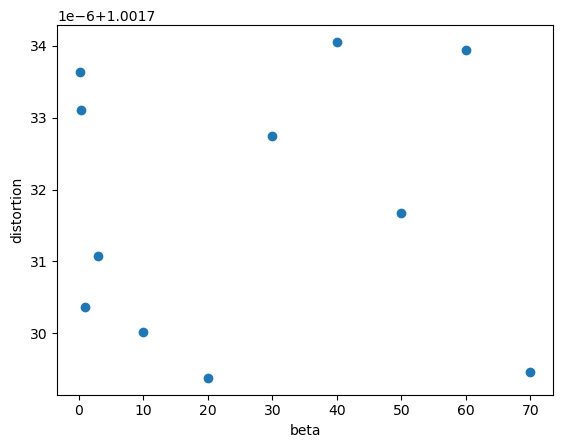

In [ ]:
distortions = []
all_betas = []
for k, v in distortions_dict.items():
    distortions.append(v)
    all_betas.append(k)

distortions = np.asarray(distortions)
all_betas = np.asarray(all_betas)

plt.scatter(x=all_betas, y=distortions)
plt.xlabel('beta')
plt.ylabel('distortion')